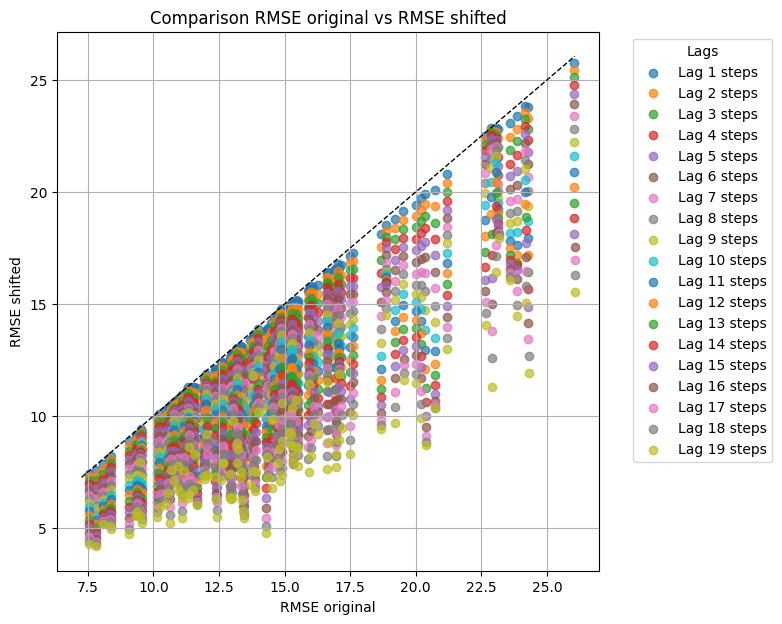

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= CONFIGURACIÓN ==========
F_HOUR = 1
MAX_STEPS = 20        
BASE_DIR = "predictions" 
STORM_START = 89
STORM_END = 108
# ==================================

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


resultados = []
for est in os.listdir(BASE_DIR):
    for storm in range(STORM_START, STORM_END + 1):
        filepath = os.path.join(BASE_DIR, est, f"predictions-{est}-storm-{storm}.csv")
        if not os.path.exists(filepath):
            continue
        df = pd.read_csv(filepath)

        obs = df[f"Observed_LDi_{est}-{F_HOUR}h"]
        pred = df[f"Predicted_LDi_{est}-{F_HOUR}h"].shift(F_HOUR*12)

        # Aplicar lag en timesteps
        for s in range(1, MAX_STEPS):
            df[f"Predicted_shifted{s}"] = df[f"Predicted_LDi_{est}-{F_HOUR}h"].shift(F_HOUR*12-s)
            # Filtrar NaN por el desplazamiento
            valid = ~df[f"Predicted_shifted{s}"].isna()
            obs_valid = obs[valid]
            pred_orig_valid = pred[valid]
            pred_shift_valid = df[f"Predicted_shifted{s}"][valid]

            # RMSE original y desplazado
            rmse_orig = rmse(obs_valid, pred_orig_valid)
            rmse_shift = rmse(obs_valid, pred_shift_valid)

            resultados.append({
                "estacion": est,
                "storm": storm,
                "RMSE_original": rmse_orig,
                f"RMSE_shifted{F_HOUR*12-s}": rmse_shift,
                "lag_usado": s,
                "F_HOUR": F_HOUR
            })


# ---- DataFrame final ----
res_df = pd.DataFrame(resultados)
# print("\nRESULTADOS POR STORM:")
#print(res_df.head())


plt.figure(figsize=(7, 7))
for s in range(1, MAX_STEPS):
    plt.scatter(res_df["RMSE_original"], res_df[f"RMSE_shifted{F_HOUR*12-s}"], alpha=0.7, label=f"Lag {s} steps")
# Línea diagonal
lims = [
    min(res_df["RMSE_original"].min(), res_df["RMSE_shifted10"].min()),
    max(res_df["RMSE_original"].max(), res_df["RMSE_shifted10"].max())
]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.legend(title="Lags", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("RMSE original")
plt.ylabel(f"RMSE shifted")
plt.title("Comparison RMSE original vs RMSE shifted")
plt.grid(True)
plt.show()


In [ ]:
PLOT = False
PLOT_ONLY_RECOVERY = True

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import metrics

errors = []

def add_error(station, storm, metric, phase, model, horizon, value):
    errors.append({
        "station": station,
        "storm_n": storm,
        "metric": metric,
        "phase": phase,
        "model": model,
        "horizon_h": horizon,
        "value": value
    })

for est in os.listdir(BASE_DIR):
    for storm in range(STORM_START, STORM_END + 1):

        # if storm != 104:
        #     continue

        filepath = os.path.join(BASE_DIR, est, f"predictions-{est}-storm-{storm}.csv")
        if not os.path.exists(filepath):
            continue
        df = pd.read_csv(filepath)
        df = df.dropna()
        df[f"Persistence_1h_LDi"] = df[f"LDi_{est}"].shift(12)
        df[f"Persistence_2h_LDi"] = df[f"LDi_{est}"].shift(24)

        df = df.dropna()

        # FULL STORM
        rmse_for_1h = rmse(df[f"Observed_LDi_{est}-1h"], df[f"Predicted_LDi_{est}-1h"])
        rmse_for_2h = rmse(df[f"Observed_LDi_{est}-2h"], df[f"Predicted_LDi_{est}-2h"])
        rmse_per_1h = rmse(df[f"Observed_LDi_{est}-1h"], df[f"Persistence_1h_LDi"])
        rmse_per_2h = rmse(df[f"Observed_LDi_{est}-2h"], df[f"Persistence_2h_LDi"])

        bfe_for_1h = metrics.calculate_BFE(df[f"Observed_LDi_{est}-1h"], df[f"Predicted_LDi_{est}-1h"])
        bfe_for_2h = metrics.calculate_BFE(df[f"Observed_LDi_{est}-2h"], df[f"Predicted_LDi_{est}-2h"])
        bfe_per_1h = metrics.calculate_BFE(df[f"Observed_LDi_{est}-{F_HOUR}h"], df[f"Persistence_1h_LDi"])
        bfe_per_2h = metrics.calculate_BFE(df[f"Observed_LDi_{est}-{F_HOUR}h"], df[f"Persistence_2h_LDi"])

        add_error(est, storm, "RMSE", "global", "forecast", 1, rmse_for_1h)
        add_error(est, storm, "RMSE", "global", "forecast", 2, rmse_for_2h)
        add_error(est, storm, "RMSE", "global", "persistence", 1, rmse_per_1h)
        add_error(est, storm, "RMSE", "global", "persistence", 2, rmse_per_2h)
        add_error(est, storm, "BFE", "global", "forecast", 1, bfe_for_1h)
        add_error(est, storm, "BFE", "global", "forecast", 2, bfe_for_2h)
        add_error(est, storm, "BFE", "global", "persistence", 1, bfe_per_1h)
        add_error(est, storm, "BFE", "global", "persistence", 2, bfe_per_2h)
        
        # print(f"\nStation {est} - Storm {storm} - FULL STORM\n"
        #       f"    RMSE For 1h: {rmse_for_1h:.4f}, RMSE Per 1h: {rmse_per_1h:.4f}, RMSE For 2h: {rmse_for_2h:.4f}, RMSE Per 2h: {rmse_per_2h:.4f}\n"
        #       f"    BFE For 1h: {bfe_for_1h:.4f}, BFE Per 1h: {bfe_per_1h:.4f}, BFE For 2h: {bfe_for_2h:.4f}, BFE Per 2h: {bfe_per_2h:.4f}")
        
        # RECOVERY PHASE
        idx_min = df[f"LDi_{est}"].idxmin()

        rmse_for_1h_rec = rmse(df[f"Observed_LDi_{est}-1h"].loc[idx_min + 1:], df[f"Predicted_LDi_{est}-1h"].loc[idx_min + 1:])
        rmse_for_2h_rec = rmse(df[f"Observed_LDi_{est}-2h"].loc[idx_min + 1:], df[f"Predicted_LDi_{est}-2h"].loc[idx_min + 1:])
        rmse_per_1h_rec = rmse(df[f"Observed_LDi_{est}-1h"].loc[idx_min + 1:], df[f"Persistence_1h_LDi"].loc[idx_min + 1:])
        rmse_per_2h_rec = rmse(df[f"Observed_LDi_{est}-2h"].loc[idx_min + 1:], df[f"Persistence_2h_LDi"].loc[idx_min + 1:])

        bfe_for_1h_rec = metrics.calculate_BFE(df[f"Observed_LDi_{est}-1h"].loc[idx_min + 1:], df[f"Predicted_LDi_{est}-1h"].loc[idx_min + 1:])
        bfe_for_2h_rec = metrics.calculate_BFE(df[f"Observed_LDi_{est}-2h"].loc[idx_min + 1:], df[f"Predicted_LDi_{est}-2h"].loc[idx_min + 1:])
        bfe_per_1h_rec = metrics.calculate_BFE(df[f"Observed_LDi_{est}-1h"].loc[idx_min + 1:], df[f"Persistence_1h_LDi"].loc[idx_min + 1:])
        bfe_per_2h_rec = metrics.calculate_BFE(df[f"Observed_LDi_{est}-2h"].loc[idx_min + 1:], df[f"Persistence_2h_LDi"].loc[idx_min + 1:])

        add_error(est, storm, "RMSE", "recovery", "forecast", 1, rmse_for_1h_rec)
        add_error(est, storm, "RMSE", "recovery", "forecast", 2, rmse_for_2h_rec)
        add_error(est, storm, "RMSE", "recovery", "persistence", 1, rmse_per_1h_rec)
        add_error(est, storm, "RMSE", "recovery", "persistence", 2, rmse_per_2h_rec)
        add_error(est, storm, "BFE", "recovery", "forecast", 1, bfe_for_1h_rec)
        add_error(est, storm, "BFE", "recovery", "forecast", 2, bfe_for_2h_rec)
        add_error(est, storm, "BFE", "recovery", "persistence", 1, bfe_per_1h_rec)
        add_error(est, storm, "BFE", "recovery", "persistence", 2, bfe_per_2h_rec)
        
        # print(f"\nStation {est} - Storm {storm} - RECOVERY ONLY\n"
        #       f"    RMSE For 1h: {rmse_for_1h_rec:.4f}, RMSE Per 1h: {rmse_per_1h_rec:.4f}, RMSE For 2h: {rmse_for_2h_rec:.4f}, RMSE Per 2h: {rmse_per_2h_rec:.4f}\n"
        #       f"    BFE For 1h: {bfe_for_1h_rec:.4f}, BFE Per 1h: {bfe_per_1h_rec:.4f}, BFE For 2h: {bfe_for_2h_rec:.4f}, BFE Per 2h: {bfe_per_2h_rec:.4f}")

        if PLOT:
            if PLOT_ONLY_RECOVERY:
                df = df.loc[idx_min + 1:]
            plt.figure(figsize=(18, 7))
            plt.plot(df[f"LDi_{est}"].values, label="Observed", linewidth=1, color='grey')
            plt.plot(df[f"Persistence_1h_LDi"].values, label="Persistence 1h", linestyle='--', linewidth=1, color='black')
            plt.plot(df[f"Persistence_2h_LDi"].values, label="Persistence 2h", linestyle=':', linewidth=1, color='black')
            plt.plot(df[f"Predicted_LDi_{est}-1h"].values, label="Forecast 1h", linewidth=0.7, color='green')
            plt.plot(df[f"Predicted_LDi_{est}-2h"].values, label="Forecast 2h", linewidth=0.7, color='blue')

            plt.title(f"Station {est} -- Storm {storm}")
            plt.xlabel("Relative time")
            plt.ylabel("LDi")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

df_errors = pd.DataFrame(errors)


Station ABG - Storm 89 - RECOVERY ONLY
    RMSE For 1h: 11.2176, RMSE Per 1h: 17.8982, RMSE For 2h: 15.9094, RMSE Per 2h: 25.1765
    BFE For 1h: 17.3518, BFE Per 1h: 29.2594, BFE For 2h: 22.8653, BFE Per 2h: 43.4268

Station ABG - Storm 90 - RECOVERY ONLY
    RMSE For 1h: 6.4319, RMSE Per 1h: 9.0715, RMSE For 2h: 8.5550, RMSE Per 2h: 10.8407
    BFE For 1h: 6.1855, BFE Per 1h: 11.1410, BFE For 2h: 7.7842, BFE Per 2h: 11.3259

Station ABG - Storm 91 - RECOVERY ONLY
    RMSE For 1h: 7.7839, RMSE Per 1h: 13.4836, RMSE For 2h: 11.2093, RMSE Per 2h: 18.1724
    BFE For 1h: 11.7746, BFE Per 1h: 19.6918, BFE For 2h: 17.1148, BFE Per 2h: 33.9387

Station ABG - Storm 92 - RECOVERY ONLY
    RMSE For 1h: 9.3716, RMSE Per 1h: 13.8360, RMSE For 2h: 12.6365, RMSE Per 2h: 17.1807
    BFE For 1h: 15.3169, BFE Per 1h: 26.8334, BFE For 2h: 23.2302, BFE Per 2h: 25.9676

Station ABG - Storm 94 - RECOVERY ONLY
    RMSE For 1h: 6.3268, RMSE Per 1h: 12.8695, RMSE For 2h: 11.2056, RMSE Per 2h: 18.4616
    B

In [ ]:
df_rec = df_errors.query("phase == 'recovery'")

mean_rec_station = (
    df_rec
    .groupby(
        ["station", "metric", "horizon_h", "model"],
        as_index=False
    )["value"]
    .mean()
)

In [37]:
rec_pivot = (
    mean_rec_station
    .query("metric == 'BFE'")
    .pivot_table(
        index=["station", "metric", "horizon_h"],
        columns="model",
        values="value"
    )
    .reset_index()
)

rec_pivot["perc_degradation_persistence"] = (
    (rec_pivot["persistence"] - rec_pivot["forecast"])
    / rec_pivot["forecast"]
    * 100
)

perc_deg_station = rec_pivot[
    ["station", "metric", "horizon_h", "perc_degradation_persistence"]
]

perc_deg_station

model,station,metric,horizon_h,perc_degradation_persistence
0,ABG,BFE,1,73.767022
1,ABG,BFE,2,72.236729
2,CLF,BFE,1,51.896046
3,CLF,BFE,2,26.516476
4,HON,BFE,1,70.250762
5,HON,BFE,2,74.930663
6,MMB,BFE,1,52.732937
7,MMB,BFE,2,39.974205
8,SFS,BFE,1,51.805268
9,SFS,BFE,2,28.373394


In [38]:
df_rec = df_errors.query("phase == 'recovery'")

storm_rec_mean = (
    df_rec
    .groupby(
        ["station", "storm_n", "metric", "horizon_h", "model"],
        as_index=False
    )["value"]
    .mean()
)

storm_pivot = (
    storm_rec_mean
    .query("metric == 'BFE'")
    .pivot_table(
        index=["station", "storm_n", "metric", "horizon_h"],
        columns="model",
        values="value"
    )
    .reset_index()
)

storm_pivot["persistence_better"] = (
    storm_pivot["persistence"] < storm_pivot["forecast"]
)

persistence_wins_with_values = (
    storm_pivot
    .loc[storm_pivot["persistence"] < storm_pivot["forecast"],
         ["station", "storm_n", "metric", "horizon_h", "forecast", "persistence"]]
    .sort_values(["station", "storm_n", "metric", "horizon_h"])
)
persistence_wins_with_values["delta_error"] = (
    persistence_wins_with_values["forecast"]
    - persistence_wins_with_values["persistence"]
)
persistence_wins_with_values["perc_improvement"] = (
    persistence_wins_with_values["delta_error"]
    / persistence_wins_with_values["forecast"]
    * 100
)


persistence_wins_with_values

model,station,storm_n,metric,horizon_h,forecast,persistence,delta_error,perc_improvement
55,CLF,98,BFE,2,11.264896,8.266643,2.998253,26.615894
61,CLF,101,BFE,2,18.675159,17.757394,0.917765,4.914365
67,CLF,104,BFE,2,64.375006,63.118907,1.256100,1.951222
71,CLF,106,BFE,2,22.192422,22.031763,0.160660,0.723939
73,CLF,107,BFE,2,22.223338,20.651906,1.571432,7.071089
75,CLF,108,BFE,2,42.254297,36.636975,5.617322,13.294085
165,SFS,96,BFE,2,17.822994,15.632200,2.190794,12.291952
176,SFS,102,BFE,1,20.945193,20.563946,0.381247,1.820214
181,SFS,104,BFE,2,54.043306,50.756041,3.287265,6.082650
183,SFS,105,BFE,2,10.798276,7.488200,3.310075,30.653740
